In [3]:
'''
1.0부터10까지의 난수를 10개 가지고 있는 두 배열 a, b를 생성하고, 두배열에 공통으로 있는 값을 출력하기
[결과]
a=[4 9 4 6 0 5 2 5 3 4]
b=[9 4 5 0 9 4 2 4 1 3]
중복데이터=[0 2 3 4 5 9]
'''
import numpy as np
a = np.random.randint(0,11,10)
b = np.random.randint(0,11,10)
print(a) #[ 4  6  5  2  8  8 10  7  8 10]
print(b) #[ 3  8  6 10  3  9  4  1  4  8]
print(np.intersect1d(a,b))


[ 4  4  1 10  5  2  8  0  5  6]
[5 9 8 7 5 2 5 5 7 2]
[2 5 8]


신림 === 서울특별시 관악구 신림동(1162069500) : 10
신림 === 강원특별자치도 원주시 신림면(5113039000) : 12
신림 === 전북특별자치도 고창군 신림면(5279042000) : 12


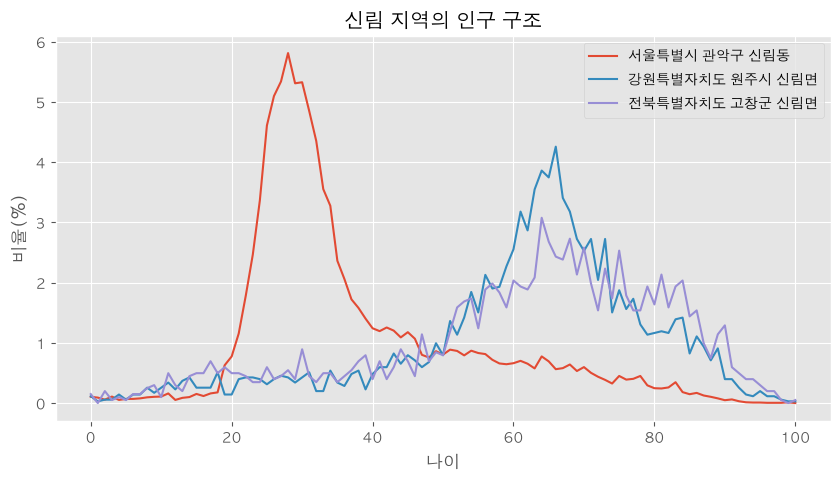

In [ ]:

'''
2. age.csv 파일에서 해당 지역의 전체 비율을 계산하여 그래프로 작성하기
20260917-1.png 이미지 참조  - csv
'''
import numpy as np
import csv
import matplotlib.pyplot as plt
import re
f =open('age.csv',encoding="CP949")
data = csv.reader(f)
next(data) #header 읽기
data=list(data) #데이터를 리스트형으로 변환.
name='신림'
homelist=[]
namelist=[]
for row in data :
     if row[0].find(name) >= 0 :
        print(name,"===",row[0],":",row[0].find(name))
        row = list(map((lambda x:x.replace(",","")),row))
        homelist.append (np.array(row[3:], dtype =int) / int(row[2]) *100)
        import re
        namelist.append(re.sub(r'\(\d*\)', '', row[0]))
        
plt.style.use('ggplot')
plt.figure(figsize = (10,5), dpi=100)
plt.rc('font', family ='AppleGothic')
plt.title(name +' 지역의 인구 구조')
for h,n in zip(homelist,namelist) :
    plt.plot(h,label=n)
plt.xlabel("나이")    
plt.ylabel("비율(%)")    
plt.legend()

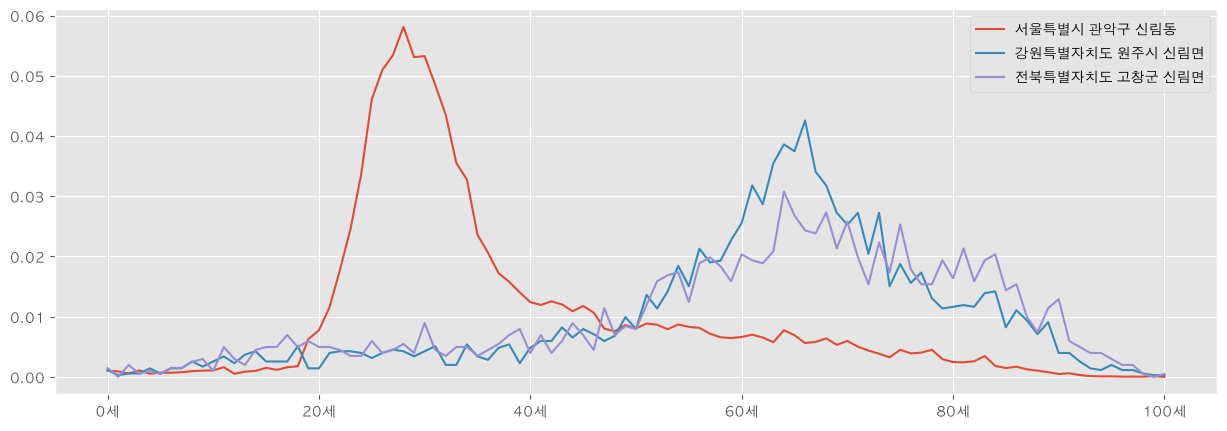

In [ ]:
'''
2. age.csv 파일에서 해당 지역의 전체 비율을 계산하여 그래프로 작성하기
20260917-1.png 이미지 참조 - pandas
'''
import numpy as np
import csv
import matplotlib.pyplot as plt
import re
import pandas as pd

df = pd.read_csv('age.csv', encoding='cp949',index_col=0,thousands=',')

col_name=['총인구수','연령구간인구수']
for i in range(0,101) :  #0 ~ 100 숫자
    col_name.append(str(i)+'세')
df.columns=col_name   #현재 컬럼의 이름을 변경
#df.div : 행의 모든 값을 총인구수로 나누기 
df = df.div(df['총인구수'],axis=0) 
del df['총인구수'],df['연령구간인구수']
name = '신림'
df.fillna(0, inplace=True)  #결측값이 존재하면 0으로 변경
# df.index : 행정구역 이름. 
a=df.index.str.contains(name) #기준 동명을 가진 인덱스를 검색
df.index = df.index.str.replace(r'\(\d*\)', '', regex=True)
df_home = df[a]
        
df_home.T.plot(figsize=(15,5))
plt.legend()

신림 === 서울특별시 관악구 신림동(1162069500) : 10
신림 === 강원특별자치도 원주시 신림면(5113039000) : 12
신림 === 전북특별자치도 고창군 신림면(5279042000) : 12


/var/folders/mh/0t1hl02s4qj6dv8cr62bzbw00000gn/T/ipykernel_3265/910955664.py:29: RuntimeWarning: invalid value encountered in divide
  away = np.array(row[3:], dtype = int) / int(row[2]) *100


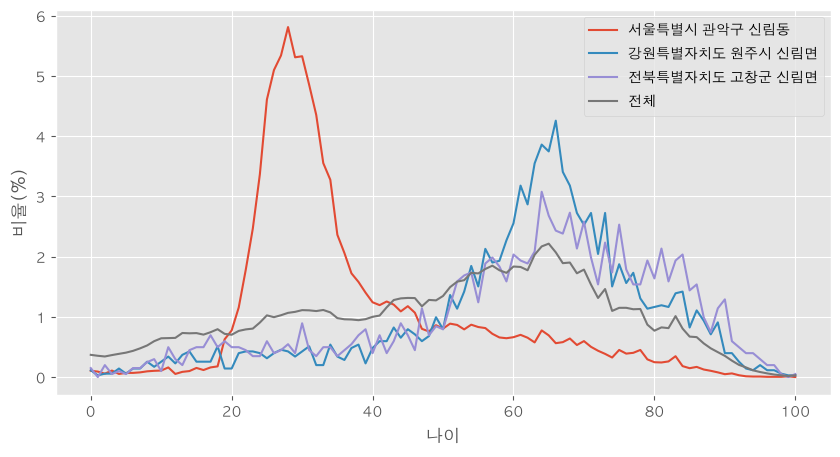

In [24]:

'''
3. age.csv 파일에서 해당 지역의 인구비율과 전체지역의 인구 비율을 함께  그래프로 작성하기
20260917-2.png 이미지 참조 - csv
'''
import numpy as np
import csv
import matplotlib.pyplot as plt
import re
f =open('age.csv',encoding="CP949")
data = csv.reader(f)
next(data)   #첫줄 헤더 정보 읽기.
data=list(data)  # data정보를 재사용
name='신림'  #선택한 지역명
homelist=[] #선택한 지역의 데이터 셋 저장 리스트
namelist=[] #선택한 지역의 이름들 저장 리스트
for row in data :
     if row[0].find(name) >= 0 :
        print(name,"===",row[0],":",row[0].find(name))
        row = list(map((lambda x:x.replace(",","")),row))
        homelist.append \
            (np.array(row[3:], dtype =int) / int(row[2]) *100) 
        import re
        namelist.append(re.sub(r'\(\d*\)', '', row[0]))
        alldata = np.array(row[3:], dtype =int) / int(row[2])*100

#전체 지역의 데이터 alldata에 저장
for row in data :
    row = list(map((lambda x:x.replace(",","")),row))
    away = np.array(row[3:], dtype = int) / int(row[2]) *100
    if np.isnan(away).any() :  #away 데이터셋에 한개라도NA값이 존재하면 
        continue    #반복문의 처음으로 
    alldata = np.vstack((alldata,away))  #행을 기준으로 연결

#연령별 인구수/전체인구수 평균값
alldata = alldata.mean(axis=0)  #열별 평균
plt.style.use('ggplot')
plt.figure(figsize = (10,5), dpi=100)
plt.rc('font', family ='AppleGothic')
for h,n in zip(homelist,namelist) :
    plt.plot(h,label=n) 
plt.plot(alldata, label="전체")
plt.xlabel("나이")    
plt.ylabel("비율(%)")    
plt.legend()


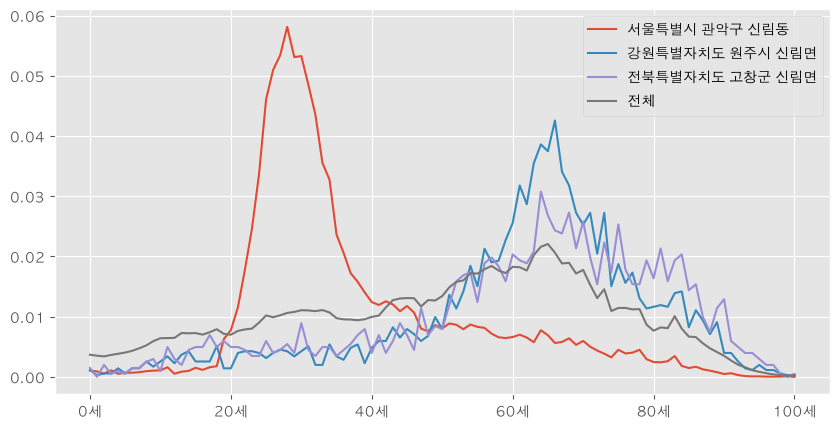

In [25]:

'''
3. age.csv 파일에서 해당 지역의 인구비율과 전체지역의 인구 비율을 함께  그래프로 작성하기
20260917-2.png 이미지 참조 - pandas
'''
import numpy as np
import csv
import matplotlib.pyplot as plt
import re
import pandas as pd

df = pd.read_csv('age.csv', encoding='cp949',index_col=0,thousands=',')

col_name=['총인구수','연령구간인구수']
for i in range(0,101) :  #0 ~ 100 숫자
    col_name.append(str(i)+'세')
df.columns=col_name   #현재 컬럼의 이름을 변경
#df.div : 행의 모든 값을 총인구수로 나누기 
df = df.div(df['총인구수'],axis=0) 
del df['총인구수'],df['연령구간인구수']
name = '신림'

df.fillna(0, inplace=True)  #결측값이 존재하면 0으로 변경

# df.index : 행정구역 이름. 
a=df.index.str.contains(name) #기준 동명을 가진 인덱스를 검색
df.index = df.index.str.replace(r'\(\d*\)', '', regex=True)
df_home = df[a]
        
df_home.T.plot(figsize=(10,5))
df.mean().T.plot(label='전체',legend=True)
plt.legend()
